## TC 5033
### Text Classifier with RNNs

<br>

#### Activity 3b: Text Classification using RNNs and AG_NEWS dataset in PyTorch
<br>

- Objective:
    - Understand the basics of Recurrent Neural Networks (RNNs) and their application in text classification.
    - Learn how to handle a real-world text dataset, AG_NEWS, in PyTorch.
    - Gain hands-on experience in defining, training, and evaluating a text classification model in PyTorch.
    
<br>

- Instructions:
    - Data Preparation: Starter code will be provided that loads the AG_NEWS dataset and prepares it for training. Do not modify this part. However, you should be sure to understand it, and comment it, the use of markdown cells is suggested.

    - Model Setup: A skeleton code for the RNN model class will be provided. Complete this class and use it to instantiate your model.

    - Implementing Accuracy Function: Write a function that takes model predictions and ground truth labels as input and returns the model's accuracy.

    - Training Function: Implement a function that performs training on the given model using the AG_NEWS dataset. Your model should achieve an accuracy of at least 80% to get full marks for this part.

    - Text Sampling: Write a function that takes a sample text as input and classifies it using your trained model.

    - Confusion Matrix: Implement a function to display the confusion matrix for your model on the test data.

    - Submission: Submit your completed Jupyter Notebook. Make sure to include a markdown cell at the beginning of the notebook that lists the names of all team members. Teams should consist of 3 to 4 members.
    
<br>

- Evaluation Criteria:

    - Correct setup of all the required libraries and modules (10%)
    - Code Quality (30%): Your code should be well-organized, clearly commented, and easy to follow. Use also markdown cells for clarity. Comments should be given for all the provided code, this will help you understand its functionality.
    
   - Functionality (60%):
        - All the functions should execute without errors and provide the expected outputs.
        - RNN model class (20%)
        - Accuracy fucntion (10%)
        - Training function (10%)
        - Sampling function (10%)
        - Confucion matrix (10%)

        - The model should achieve at least an 80% accuracy on the AG_NEWS test set for full marks in this criterion.


Dataset

https://pytorch.org/text/stable/datasets.html#text-classification

https://paperswithcode.com/dataset/ag-news


#### Install libraries (if needed)

You may need to install the following libraries, also you may need to adjust library versions to ensure compatibility, depending on the versions you have previously installed. After installing them, please Restart the Session (Runtime -> Restart Session), or Kernel - Restart Kerne

In [66]:
# !pip install torch==2.2.0 torchvision==0.17.0 torchaudio==2.2.0 torchtext==0.16.2

In [67]:
# !pip install scipy==1.9.3
# !pip install scikit-plot
#you may receive a message of restarting session, this is OK

In [68]:
# !pip install portalocker
#please restar session after this intallation. After restarting go straight to importing the libraries

## Import libraries

In [69]:
# The following libraries are required for running the given code
# Please feel free to add any libraries you consider adecuate to complete the assingment.
import numpy as np
#PyTorch libraries
import torch
from torchtext.datasets import AG_NEWS
# Dataloader library
from torch.utils.data import DataLoader
from torch.utils.data.dataset import random_split
# Libraries to prepare the data
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from torchtext.data.functional import to_map_style_dataset
# neural layers
from torch import nn
from torch.nn import functional as F

# These libraries are suggested to plot confusion matrix
# you may use others
import scikitplot as skplt
import gc

import torchdata

In [70]:
# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


### Get the train and the test datasets and dataloaders

Classes:

* 1 - World

* 2 - Sports

* 3 - Business

* 4 - Sci/Tech

We will convert them to:

* 0 - World

* 1 - Sports

* 2 - Business

* 3 - Sci/Tech

In [71]:
train_dataset, test_dataset = AG_NEWS()
#to_map_style_dataset hace que el dataset sea iterable
train_dataset, test_dataset = to_map_style_dataset(train_dataset), to_map_style_dataset(test_dataset)

In [72]:
# Get the tokeniser
# tokeniser object
tokeniser = get_tokenizer('basic_english') # divide el texto en palabras utilizando las reglas básicas de inglés:
'''
- convierte a minúsculas
- separa por espacios
- separa puntuación
- maneja contracciones simples

ejemplo práctico:
input ---> tokeniser("Hello, world! It's great.")
output ---> ['hello', 'world', 'it', "'s", 'great', '.']
'''

def yield_tokens(data):
    # AG_NEWS viene como unalista de tuplas que contiene lo siguiente (no, news), por eso necesitas el _
    for _, text in data:
        yield tokeniser(text) #aqui sólo llamamos al tokeniser para que aplique las reglas del comment de arriba

In [73]:
# Build the vocabulary
'''
build_vocab_from_iterator implica
    - recorre TODO el dataset de entrenamiento
    - tokeniza cada texto usando yield_tokens
    - cuenta cuántas veces aparece cada token
    - asigna un índice numérico a cada palabra
Ejemplo conceptual:
"the" → 5
"market" → 123
"president" → 87
el unk se asigna a todas aquellas palabras que no estén dentro del vocabulario 
'''
vocab = build_vocab_from_iterator(yield_tokens(train_dataset), specials=["<unk>", "<pad>"])
'''
agrego el <pad> en caso de que la oración no tenga los tokens máximos, esto beneficia el funcionamiento del código
esto ayuda debido a que una RNN, LSTM, o GRU necesita los vectores con la misma longitud para funcionar correctamente
el padding solo rellena los tokens faltantes con 0
'''
#set unknown token at position 0
vocab.set_default_index(vocab["<unk>"])# se asugura de que se asigna unk como primera posición 
PAD_IDX = vocab["<pad>"] #sólo se asigna un índice al padding


In [74]:
#test tokens
tokens = tokeniser('Welcome to TC5033')
print(tokens, vocab(tokens))
#BÁSICAMNETE CON EL TC5033 PROBAMOS QUE SEA ASIGNADO EL UNK CON VALOR 0

['welcome', 'to', 'tc5033'] [3315, 5, 0]


In [75]:
NUM_TRAIN = int(len(train_dataset)*0.9)
NUM_VAL = len(train_dataset) - NUM_TRAIN

In [76]:
train_dataset, val_dataset = random_split(train_dataset, [NUM_TRAIN, NUM_VAL])

In [77]:
print(len(train_dataset), len(val_dataset), len(test_dataset))

108000 12000 7600


In [78]:
# function passed to the DataLoader to process a batch of data as indicated
def collate_batch(batch):
    # Get label and text
    y, x = list(zip(*batch)) # y son etiquetas | x son textos

    # Create list with indices from tokeniser
    x = [vocab(tokeniser(text)) for text in x] #tokenisa y convierte los índices
    '''
    como agegué arriba el <pad>, entocnes modifico la linea 
            x = [t + ([0]*(max_tokens - len(t))) if len(t) < max_tokens else t[:max_tokens] for t in x]
    porque:
        - el modelo no podía disitnguir el ruido generado por no tener el vector con la misma longitud y el unkown
        - 0 era lo mismo para unk y padding
    en otras palabras, el modelo no distinguía entre palabra no conocida en el vocab y el ruido o relleno para poder ignorarlo
    '''
    x = [t + ([PAD_IDX] * (max_tokens - len(t))) if len(t) < max_tokens else t[:max_tokens] for t in x]
    '''
    al cambiar [0] por PAD_IDX el modelo aprende a distinguir el relleno e ignorarlo y a distinguir entre relleno y palabra desconocida
    '''

    # Prepare the labels, by subtracting 1 to get them in the range 0-3 ---> this is applied in y
    return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long) - 1

### TABLA CON LA EXPLICACIÓN DE PADDING

|VERSION|VALOR USADO|SIGNIFICADO|PROBLEMA|
|-------|-----------|-----------|--------|
|x = [t + ([0]*...]|0|UNK|El modelo confunde padding con palabras desconocidas|
|x = [t + ([PAD_IDX]*...]|PAD_IDX|<PAD>|El modelo distingue padding (relleno/ruido) de palabras reales|

In [79]:
labels =  ["World", "Sports", "Business", "Sci/Tech"]
max_tokens = 50
BATCH_SIZE = 256
criterion = nn.CrossEntropyLoss()

In [80]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle = True)

### Let us build our RNN model

In [81]:
EMBEDDING_SIZE = 300
NEURONS = 256
LAYERS = 2
NUM_CLASSES = 4

### Comparación entre RNN, GRU y LSTM
|Arquitectura|Cómo funciona|Qué recuerda|Ventajas|Desventajas|Cuándo usarla|
|--------|--------|--------|--------|--------|--------|
|RNN (Simple RNN)|Cada paso actualiza un estado oculto con una operación lineal + tanh|Muy poco; memoria corta|Rápida, simple, ligera|Sufre vanishing gradients, olvida rápido, pobre para secuencias largas|Textos muy cortos, prototipos, cuando quieres entender lo básico|
|GRU (Gated Recurrent Unit)|Usa dos compuertas: actualización y reinicio|Memoria media; mejor que RNN|Más simple que LSTM, entrena rápido, buen rendimiento|Menos control explícito que LSTM|Secuencias medianas, clasificación de texto, NLP general|
|LSTM (Long Short-Term Memory)|Usa tres compuertas: entrada, olvido, salida + celda de memoria|Memoria larga; excelente para dependencias largas|Mejor capacidad de memoria, muy estable|Más lento, más parámetros|Secuencias largas, tareas complejas, modelos que necesitan recordar mucho|



🧠 Interpretación intuitiva
- RNN → “memoria de pez dorado”
Recuerda muy poco. Bueno para secuencias cortas.
- GRU → “memoria razonable”
Decide qué olvidar y qué mantener. Balance ideal entre velocidad y calidad.
- LSTM → “memoria de elefante”
Puede recordar información muy lejana en la secuencia.

🧩 ¿Qué significa esto para tu proyecto AG_NEWS?
Los textos de AG_NEWS:
- no son muy largos
- no requieren dependencias de largo plazo
- necesitan velocidad para entrenar


Representación gráfica:

       x_t (Entrada actual) ----+------>[Reset Gate (r_t)]

                                |              |
       h_{t-1} (Estado anterior)+------>[Update Gate (z_t)]

                                |              |
                                V              V
                         [Estado Candidato h~t]--->[Operaciones Elementales]---> h_t (Nuevo Estado)

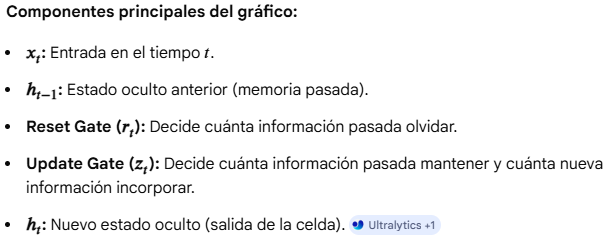


In [82]:
class RNN_Model_1(nn.Module):
    def __init__(self, embed_size, hidden, layers, num_classes):
        super().__init__()
        self.embedding_layer = nn.Embedding(num_embeddings=len(vocab), embedding_dim=embed_size)
        '''
        Esto convierte:
            - entrada: (batch_size, max_tokens)
            - salida: (batch_size, max_tokens, embed_size)
        '''
        self.rnn = nn.GRU(input_size=embed_size, hidden_size=hidden, num_layers=layers, batch_first=True, dropout=0.1, bidirectional=True)
                        

        self.fc = nn.Linear(in_features=hidden*2, out_features=num_classes)

    def forward(self, x):
        #Pasar x por el embedding
        embeddings= self.embedding_layer(x)
        #Pasar embeddings por la GRU
        output, h_t= self.rnn(embeddings) #esto da como restulado un tensor 3D con forma
                                          # (num_ layers * directions,batch,hidden)
                                          # y su comportamiento es similar al de una lista, es dicr, como si tuviera 1 eje

        '''
        Tomar el último hidden state (de ambas direcciones)

        debido a que el comportamiento es similar al de una lista, tengo 4 renglones que son:
            - h_t[0] = capa 0 forward
            - h_t[1] = capa 0 backward
            - h_t[2] = capa 1 forward
            - h_t[3] = capa 1 backward
        h_t tiene forma (num_layers * num_directions, batch_size, hidden_size)
        al tener bidirectional=TRUE, entonces tengo 2 direcciones [forward y backward]
        el motivo por el cual yo tengo 4 índices, es porque tengo 2 salidas (bidirectional=TRUE) y 2 layers, es dicr, 2X2=4 índices
        de manera más abtracta, los indices resultand e multiplicar las salidas X layers
        '''
        hidden_fwd = h_t[-2] #lo paso a negativo para que lea la "lista" / tensor al revés
        hidden_bwd= h_t[-1]
        #concatenar los hidden states
        #h_final = concatenar(h_forward, h_backward)
        #recuerda que es una lista de tensores; entonces: ([h_fwd,h_bwd], features)
        h_fin = torch.cat([hidden_fwd, hidden_bwd], dim=1) # produce una salida con forma (batch, hidden * 2)
        #Pasarlo por la capa lineal el úlitmo hidden state
        logits= self.fc(h_fin)
        #Regresar logits
        return logits


### Tabla: Parámetros de nn.GRU y su significado
|Parámetro|Tipo|Qué significa|Cómo afecta al modelo|Cuándo cambiarlo|Interpretación intuitiva|
|-----|-----|-----|-----|-----|-----|
|input_size|int|Dimensión del embedding que entra a la GRU|Debe coincidir con **embed_size**|Nunca lo cambias manualmente; siempre igual al embedding|qué tan grande es cada palabra|
|hidden_size|int|Tamaño del vector oculto que la GRU mantiene en cada paso|Más grande = más capacidad de memoria, pero más lento|64–256 es típico para clasificación|qué tan grande es la memoria de la GRU|
|num_layers|int|Número de capas GRU apiladas|Más capas = modelo más profundo|1–2 capas es suficiente para AG_NEWS|cuántas GRUs apiladas|
|batch_first|bool|Si True, la entrada es (batch, seq, features)|Debe ser True para que tu batch funcione|Siempre ponlo en True|tu batch entra como (256, 50, embed_size)|
|dropout|float|Dropout entre capas (solo si num_layers > 1)|Reduce overfitting|0.1–0.3 si usas 2+ capas|evita que memorice demasiado|
|bidirectional|bool|Si True, procesa la secuencia hacia adelante y hacia atrás|Duplica la capacidad, pero también los parámetros|Útil, pero más pesado; opcional|lee el texto en dos direcciones|
|device|torch.device|En qué dispositivo corre la GRU|CPU o GPU|Ya lo estás usando bien| 

In [83]:
def accuracy(model, loader):
    #poner el modelo en modo evaluación
    model.eval()
    correct =0
    total=0
    #desactivar gradientes
    with torch.no_grad():
        #recorrer el dataloader
        for batch in loader: #iterar sobre las entradas del batch
            #x ---> textos tokenizados | y ---> labels
            x,y= batch #las etiquetas verdaderas
            logits = model(x) #extrae logits
            #las predicciones (argmax)
            preds = logits.argmax(dim=1) # argmax devuelve el índice de la clase más probable
                                         # dim=1 cada fila del batch contiene los logits de la clase
            #comparar predicciones vs etiquetas
            correct += (preds == y).sum().item() #compara etiquetas y suma las TRUE
            total += y.size(0) # tiene la forma (batch_size,), y es size(0) para que te quedes con la primer dimensión
    return correct / total #regresa el porcentaje de aciertos

In [87]:
def train(model, optimiser, epochs=100):
    for epoch in range(epochs):
        model.train()
        epoch_loss=0
        num_batches =0
        for batch in train_loader:
            optimiser.zero_grad() #reseteamos gradientes
            x, y = batch
            logits = model(x)
            loss = criterion(logits, y) #cálculo de pérdida
            loss.backward() #backward prop
            optimiser.step() #actualiza parámetros
            epoch_loss += loss.item() #acumula la pérdida por epoch
            num_batches += 1
        epoch_loss = epoch_loss / num_batches
        print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

In [85]:
epochs = 10
lr = 0.0001
# instantiate model
rnn_model = RNN_Model_1(EMBEDDING_SIZE, NEURONS, LAYERS, NUM_CLASSES)
rnn_model.to(device=device)
optimiser = torch.optim.Adam(rnn_model.parameters(), lr=lr)


In [88]:
train(rnn_model, optimiser=optimiser,  epochs=epochs)

Epoch 1, Loss: 0.2814
Epoch 2, Loss: 0.2377
Epoch 3, Loss: 0.2061
Epoch 4, Loss: 0.1802
Epoch 5, Loss: 0.1590
Epoch 6, Loss: 0.1386
Epoch 7, Loss: 0.1229
Epoch 8, Loss: 0.1083
Epoch 9, Loss: 0.0928
Epoch 10, Loss: 0.0837


In [89]:
print(f'{accuracy(rnn_model, test_loader):.4f}')

0.8993


In [90]:
def sample_text(model, loader, vocab):
    model.eval()
    # significado de las labels
    label_names = {
        0: "World",
        1: "Sports",
        2: "Business",
        3: "Sci/Tech"
    }
    pad_index = 1  #indica el idx del pad, para que así lo pueda ubicar dentro del vocab
    with torch.no_grad():
        # Tomamos un solo batch
        for x, y in loader:
            logits = model(x)
            preds = logits.argmax(dim=1)
            # Tomamos solo los primeros 5 ejemplos
            for i in range(5):
                # Reconstruir texto ignorando <pad>
                tokens = [vocab.lookup_token(idx.item()) #el lookup token es el que busca la palabra en el vocabulario
                          for idx in x[i] if idx.item() != pad_index]
                text = " ".join(tokens)#se unen los tokens/palabras y se agrega el espacio para que sea leible
                true_label = label_names[y[i].item()]
                pred_label = label_names[preds[i].item()]
                print("------------------------------------------------------------")
                print(f"Texto:      {text}")
                print(f"Etiqueta:   {true_label}")
                print(f"Predicción: {pred_label}")
                print("------------------------------------------------------------\n")
            break

In [91]:
sample_text(rnn_model, test_loader, vocab)

------------------------------------------------------------
Texto:      alitalia union may accept job cuts a top italian labor leader says his union could consider job cuts at alitalia to prevent the airline #39 s collapse , as workers at the flag carrier <unk> for details of its cost-cutting rescue plan .
Etiqueta:   Business
Predicción: Business
------------------------------------------------------------

------------------------------------------------------------
Texto:      sony-led group to acquire mgm for \$3b los angeles sept . 13 , 2004 - a consortium led by sony corp . has agreed in principle to acquire famed hollywood studio metro-goldwyn-mayer inc .
Etiqueta:   Business
Predicción: Sci/Tech
------------------------------------------------------------

------------------------------------------------------------
Texto:      israeli labour amp sharon in coalition talks coalition peace talks have begun between israel #39 s opposition labour party and the prime minister , ari

In [92]:
# create confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(model, loader):
    # Nombres de clase
    labels = ["World", "Sports", "Business", "Sci/Tech"]

    y_true = []#lista para el eje x
    y_pred = []#lista para el eje Y

    model.eval()
    with torch.no_grad():
        for x, y in loader:
            logits = model(x)
            preds = logits.argmax(dim=1)

            y_true.extend(y.tolist()) #agrega los elementos a la lista, expandiendo sus elementos, el append los anida
            y_pred.extend(preds.tolist())

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)

    # Heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicción")
    plt.ylabel("Etiqueta verdadera")
    plt.title("Matriz de Confusión - AG_NEWS")
    plt.show()

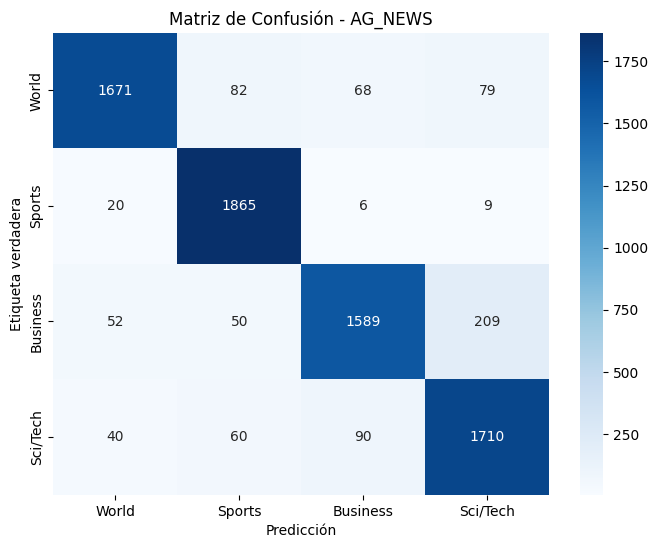

In [93]:
plot_confusion_matrix(rnn_model, test_loader)